# Modelo de Otimização de Orçamento

**Projeto:** Social Wave — Otimização de Campanhas de Marketing  
**Fase:** Recomendação (Fase 3)  
**Objetivo:** Encontrar a alocação de orçamento que minimiza o CPA global

---

## Perguntas que este notebook responde

| # | Pergunta | O que descobrimos | Seção |
|---|----------|-------------------|-------|
| **3.1** | Qual a **alocação ótima** de orçamento entre canais? | Distribuição ideal para minimizar CPA | 3.1 |
| **3.2** | Qual o **CPA projetado** com a alocação ótima vs. atual? | Ganho de eficiência | 3.2 |
| **3.3** | Qual o **risco** de realocar verba (perda de volume)? | Trade-off custo vs. volume | 3.3 |

---

## Dados de Entrada
Base processada (`campanhas_base_processada.pkl`)  
Resumo por canal (`resumo_por_canal.pkl`)

---

## Entregáveis
- Alocação ótima de orçamento por canal (%)
- CPA projetado: atual vs. otimizado
- Análise de trade-off: custo vs. volume

## Setup e Carregamento

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURAÇÕES VISUAIS
# ============================================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

np.random.seed(42)

# ============================================================
# CARREGAR DADOS
# ============================================================

PICKLE_PATH = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\campanhas_base_processada.pkl'
RESUMO_PATH = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_por_canal.pkl'

try:
    df = pd.read_pickle(PICKLE_PATH)
    resumo = pd.read_pickle(RESUMO_PATH)
    
    print('=' * 60)
    print('📊 DADOS CARREGADOS')
    print('=' * 60)
    print(f'Base: {PICKLE_PATH}')
    print(f'   Dimensoes: {df.shape[0]:,} x {df.shape[1]}')
    print(f'Resumo: {RESUMO_PATH}')
    print(f'   Canais: {len(resumo)}')
    
    print(f'\n📊 Resumo por canal:')
    print(resumo[['Gasto_Total', 'Conversao_Total', 'CPA']].to_string())
    
except FileNotFoundError as e:
    print(f'❌ Arquivo nao encontrado: {e}')
    print('   Execute os Notebooks 01 e 02 primeiro.')
    raise

📊 DADOS CARREGADOS
Base: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\campanhas_base_processada.pkl
   Dimensoes: 23,315 x 9
Resumo: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_por_canal.pkl
   Canais: 6

📊 Resumo por canal:
               Gasto_Total  Conversao_Total   CPA
Canal_Nome                                       
Meta Ads        6040563.96          1556536  3.88
Twitter Ads    12624414.68          2598483  4.86
TikTok          5622544.31           366198 15.35
YouTube Ads    14523324.07           533457 27.22
Google Search  26104521.92           640473 40.76
LinkedIn Ads     785726.71            16552 47.47


## Modelo de Alocação Ótima

Construção de um modelo de otimização que encontra a distribuição percentual de orçamento entre canais que minimiza o CPA global. 
O modelo respeita:

    Orçamento total fixo (mesmo gasto, melhor alocado)
    Nenhum canal pode receber 0% (manter presença mínima)
    CPA de cada canal como função do investimento (retornos decrescentes)

In [4]:
print('=' * 60)
print('🎯 MODELO DE ALOCAÇÃO ÓTIMA')
print('=' * 60)

# ============================================================
# PREPARAR DADOS DO MODELO
# ============================================================

print('\n' + '-' * 60)
print('DADOS DO MODELO')
print('-' * 60)

# Extrair dados por canal
canais = resumo.index.tolist()
n_canais = len(canais)

# Gasto total atual (orçamento a ser otimizado)
gasto_total = resumo['Gasto_Total'].sum()

# CPA atual por canal
cpa_atual = resumo['CPA'].values

# Conversões atuais por canal
conversoes_atual = resumo['Conversao_Total'].values

# Share de gasto atual
share_atual = resumo['Share_Gasto'].values / 100

print(f'\n📊 Orçamento total: ${gasto_total:,.2f}')
print(f'📊 Canais: {n_canais}')
print(f'\nCanal              CPA Atual  Share Atual   Gasto Atual')
print('-' * 60)

for i, canal in enumerate(canais):
    print(f'{canal:<18} ${cpa_atual[i]:>8.2f} {share_atual[i]*100:>10.1f}% ${resumo.loc[canal, "Gasto_Total"]:>10,.2f}')

# ============================================================
# FUNÇÃO OBJETIVO: CPA GLOBAL
# ============================================================

print('\n' + '-' * 60)
print('FUNÇÃO OBJETIVO')
print('-' * 60)

def calcular_cpa_global(share, cpa_base, gasto_total, elasticidade=0.3):
    '''
    Calcula CPA global dado um vetor de shares.
    
    Modelo de retornos decrescentes:
    CPA_canal = CPA_base * (1 + elasticidade * ln(share / share_base))
    
    Se share aumenta em relação ao base, CPA sobe (saturação).
    Se share diminui, CPA cai (menos saturado).
    '''
    share_base = share_atual  # share atual como referência
    
    # Evitar log de zero ou negativo
    ratio = share / share_base
    ratio = np.maximum(ratio, 0.01)  # mínimo 1% do share base
    
    # CPA ajustado por canal (retornos decrescentes)
    cpa_ajustado = cpa_base * (1 + elasticidade * np.log(ratio))
    
    # Garantir CPA positivo
    cpa_ajustado = np.maximum(cpa_ajustado, cpa_base * 0.5)
    
    # Gasto por canal
    gasto_canal = share * gasto_total
    
    # Conversões por canal
    conversoes_canal = gasto_canal / cpa_ajustado
    
    # CPA global = gasto total / conversões totais
    conversoes_total = conversoes_canal.sum()
    
    if conversoes_total > 0:
        cpa_global = gasto_total / conversoes_total
    else:
        cpa_global = float('inf')
    
    return cpa_global, cpa_ajustado, conversoes_canal

# Testar com alocação atual
cpa_global_atual, cpa_aj_canal, conv_atual = calcular_cpa_global(share_atual, cpa_atual, gasto_total)

print(f'\n📐 Teste com alocação ATUAL:')
print(f'   CPA global calculado: ${cpa_global_atual:.2f}')
print(f'   CPA global do resumo: ${gasto_total / conversoes_atual.sum():.2f}')

# ============================================================
# OTIMIZAÇÃO
# ============================================================

print('\n' + '-' * 60)
print('OTIMIZAÇÃO')
print('-' * 60)

from scipy.optimize import minimize

# Função objetivo (minimizar CPA global)
def objetivo(share):
    cpa_global, _, _ = calcular_cpa_global(share, cpa_atual, gasto_total)
    return cpa_global

# Restrições:
# 1. Soma dos shares = 1 (100%)
# 2. Cada share >= 5% (presença mínima em cada canal)
# 3. Cada share <= 50% (não concentrar tudo)

def restricao_soma(share):
    return share.sum() - 1.0

# Bounds: cada share entre 5% e 50%
bounds = [(0.05, 0.50) for _ in range(n_canais)]

# Restrição de igualdade (soma = 1)
restricoes = {'type': 'eq', 'fun': restricao_soma}

# Chute inicial: alocação atual (ajustada se necessário)
x0 = share_atual.copy()
x0 = np.maximum(x0, 0.05)  # mínimo 5%
x0 = np.minimum(x0, 0.50)  # máximo 50%
x0 = x0 / x0.sum()  # normalizar para somar 1

print(f'\n📊 Chute inicial (share atual ajustado):')
for i, canal in enumerate(canais):
    print(f'   {canal}: {x0[i]*100:.1f}%')

# Executar otimização
resultado = minimize(
    objetivo,
    x0,
    method='SLSQP',
    bounds=bounds,
    constraints=restricoes,
    options={'ftol': 1e-9, 'disp': False, 'maxiter': 1000}
)

if resultado.success:
    share_otimo = resultado.x
    cpa_global_otimo, cpa_aj_otimo, conv_otimo = calcular_cpa_global(share_otimo, cpa_atual, gasto_total)
    
    print(f'\n✅ OTIMIZAÇÃO CONCLUÍDA!')
    print(f'   CPA global ótimo: ${cpa_global_otimo:.2f}')
    print(f'   CPA global atual: ${cpa_global_atual:.2f}')
    reducao_pct = ((cpa_global_atual - cpa_global_otimo) / cpa_global_atual * 100)
    print(f'   Redução de CPA: {reducao_pct:.1f}%')
else:
    print(f'\n❌ Otimização falhou: {resultado.message}')
    share_otimo = x0.copy()
    cpa_global_otimo = cpa_global_atual
    cpa_aj_otimo = cpa_atual.copy()
    conv_otimo = conversoes_atual.copy()

# ============================================================
# RESULTADOS: ALOCAÇÃO ÓTIMA VS. ATUAL
# ============================================================

print('\n' + '-' * 60)
print('RESULTADOS: ALOCAÇÃO ÓTIMA VS. ATUAL')
print('-' * 60)

resultados_df = pd.DataFrame({
    'Canal': canais,
    'Share_Atual_Pct': (share_atual * 100).round(1),
    'Share_Otimo_Pct': (share_otimo * 100).round(1),
    'Diferenca_Pct': ((share_otimo - share_atual) * 100).round(1),
    'CPA_Atual': cpa_atual.round(2),
    'CPA_Ajustado_Otimo': cpa_aj_otimo.round(2)
})

print(f'\nCanal              Atual    Ótimo       Δ    CPA Atual   CPA Adj.')
print('-' * 70)

for _, row in resultados_df.iterrows():
    diff = row['Diferenca_Pct']
    if diff > 1:
        seta = '⬆️'
    elif diff < -1:
        seta = '⬇️'
    else:
        seta = '➖'
    print(f'{row["Canal"]:<18} {row["Share_Atual_Pct"]:>6.1f}% {row["Share_Otimo_Pct"]:>6.1f}% {diff:>+7.1f}% ${row["CPA_Atual"]:>8.2f} ${row["CPA_Ajustado_Otimo"]:>8.2f} {seta}')

# ============================================================
# IMPACTO AGREGADO
# ============================================================

print('\n' + '-' * 60)
print('IMPACTO AGREGADO')
print('-' * 60)

conversoes_total_atual = conversoes_atual.sum()
conversoes_total_otimo = conv_otimo.sum()

print(f'\n📊 Cenário ATUAL:')
print(f'   Gasto total:     ${gasto_total:,.2f}')
print(f'   Conversões:      {conversoes_total_atual:,.0f}')
print(f'   CPA global:      ${cpa_global_atual:.2f}')

print(f'\n📊 Cenário ÓTIMO:')
print(f'   Gasto total:     ${gasto_total:,.2f}')
print(f'   Conversões:      {conversoes_total_otimo:,.0f}')
print(f'   CPA global:      ${cpa_global_otimo:.2f}')

ganho_conversoes = ((conversoes_total_otimo / conversoes_total_atual) - 1) * 100
reducao_cpa = ((cpa_global_atual - cpa_global_otimo) / cpa_global_atual) * 100

print(f'\n🎯 GANHO:')
print(f'   Redução de CPA:  {reducao_cpa:.1f}%')
print(f'   Ganho de conv.:  {ganho_conversoes:.1f}%')
print(f'   Conversões a mais: {conversoes_total_otimo - conversoes_total_atual:,.0f}')

print('\n' + '=' * 60)
print('🚀 MODELO DE ALOCAÇÃO ÓTIMA CONCLUÍDO!')
print('=' * 60)

🎯 MODELO DE ALOCAÇÃO ÓTIMA

------------------------------------------------------------
DADOS DO MODELO
------------------------------------------------------------

📊 Orçamento total: $65,701,095.65
📊 Canais: 6

Canal              CPA Atual  Share Atual   Gasto Atual
------------------------------------------------------------
Meta Ads           $    3.88        9.2% $6,040,563.96
Twitter Ads        $    4.86       19.2% $12,624,414.68
TikTok             $   15.35        8.6% $5,622,544.31
YouTube Ads        $   27.22       22.1% $14,523,324.07
Google Search      $   40.76       39.7% $26,104,521.92
LinkedIn Ads       $   47.47        1.2% $785,726.71

------------------------------------------------------------
FUNÇÃO OBJETIVO
------------------------------------------------------------

📐 Teste com alocação ATUAL:
   CPA global calculado: $11.51
   CPA global do resumo: $11.50

------------------------------------------------------------
OTIMIZAÇÃO
---------------------------------

## Gráfico: Alocação Atual vs. Ótima

Visualiza lado a lado a alocação atual e a alocação ótima de orçamento por canal. 

Setas indicam quais canais ganham ou perdem verba. 

É o gráfico principal para recomendação a gestores.

📊 GRÁFICO: ALOCAÇÃO ATUAL VS. ÓTIMA
✅ Figura salva: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\09_alocacao_atual_vs_otima.png


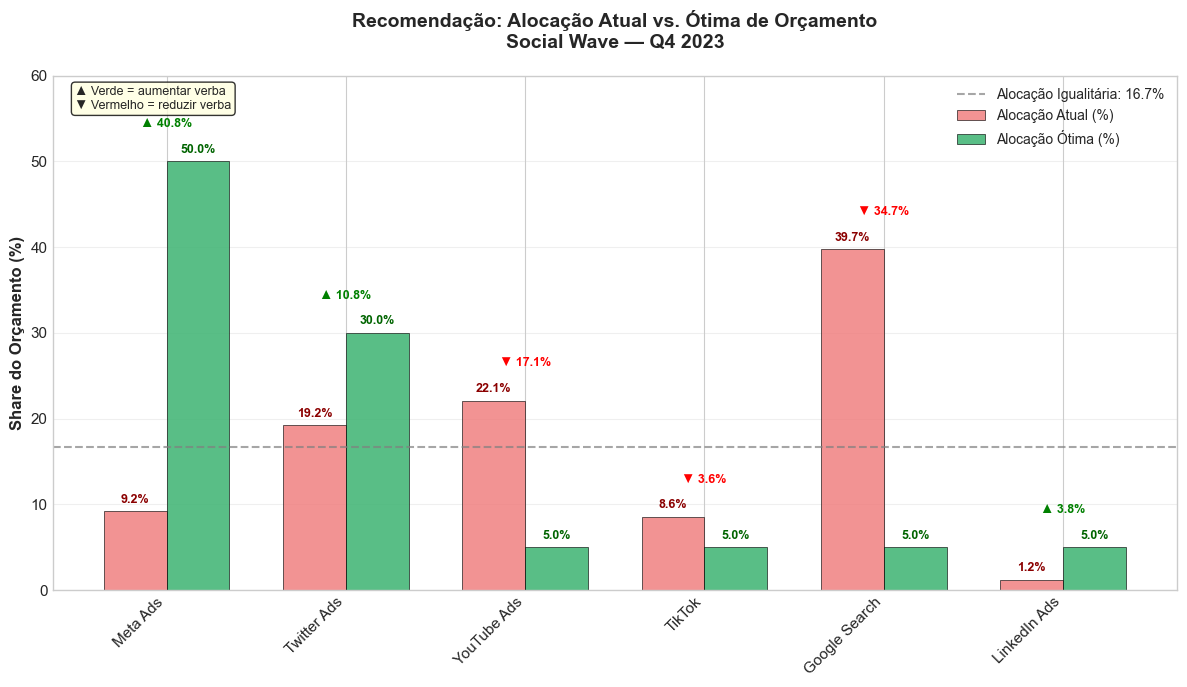


📋 TABELA DE REALOCAÇÃO

Canal              Atual    Ótimo      Δ        Ação
-----------------------------------------------------------------
Meta Ads              9.2%   50.0%  +40.8% ▲ AUMENTAR verba
Twitter Ads          19.2%   30.0%  +10.8% ▲ AUMENTAR verba
YouTube Ads          22.1%    5.0%  -17.1% ▼ REDUZIR verba
TikTok                8.6%    5.0%   -3.6% ▼ REDUZIR verba
Google Search        39.7%    5.0%  -34.7% ▼ REDUZIR verba
LinkedIn Ads          1.2%    5.0%   +3.8% ▲ AUMENTAR verba

🚀 GRÁFICO DE ALOCAÇÃO COMPLETO!


In [5]:
print('=' * 60)
print('📊 GRÁFICO: ALOCAÇÃO ATUAL VS. ÓTIMA')
print('=' * 60)

# ============================================================
# PREPARAR DADOS
# ============================================================

# Usar resultados da célula anterior
dados_plot = pd.DataFrame({
    'Canal': canais,
    'Atual': share_atual * 100,
    'Otimo': share_otimo * 100
})

dados_plot['Diferenca'] = dados_plot['Otimo'] - dados_plot['Atual']
dados_plot = dados_plot.sort_values('Otimo', ascending=False)

# ============================================================
# CRIAR GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(dados_plot))
largura = 0.35

# Barras: alocação atual
barras_atual = ax.bar(
    x - largura/2,
    dados_plot['Atual'],
    largura,
    label='Alocação Atual (%)',
    color='lightcoral',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.85
)

# Barras: alocação ótima
barras_otimo = ax.bar(
    x + largura/2,
    dados_plot['Otimo'],
    largura,
    label='Alocação Ótima (%)',
    color='mediumseagreen',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.85
)

# ============================================================
# ADICIONAR VALORES E SETAS
# ============================================================

for i, row in dados_plot.iterrows():
    idx = dados_plot.index.get_loc(i)
    
    # Valor atual
    ax.text(
        idx - largura/2,
        row['Atual'] + 1,
        f'{row['Atual']:.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='darkred'
    )
    
    # Valor ótimo
    ax.text(
        idx + largura/2,
        row['Otimo'] + 1,
        f'{row['Otimo']:.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='darkgreen'
    )
    
    # Seta de variação
    diff = row['Diferenca']
    if abs(diff) > 2:
        y_pos = max(row['Atual'], row['Otimo']) + 4
        cor_seta = 'green' if diff > 0 else 'red'
        simbolo = '▲' if diff > 0 else '▼'
        ax.text(
            idx,
            y_pos,
            f'{simbolo} {abs(diff):.1f}%',
            ha='center',
            fontsize=9,
            fontweight='bold',
            color=cor_seta
        )

# ============================================================
# CONFIGURAR ESTILO
# ============================================================

ax.set_xticks(x)
ax.set_xticklabels(dados_plot['Canal'], rotation=45, ha='right')
ax.set_ylabel('Share do Orçamento (%)', fontsize=12, fontweight='bold')
ax.set_title(
    'Recomendação: Alocação Atual vs. Ótima de Orçamento\nSocial Wave — Q4 2023',
    fontsize=14,
    fontweight='bold',
    pad=20
)

# Linha de referência: alocação igualitária (16.67%)
alocacao_igual = 100 / 6
ax.axhline(
    y=alocacao_igual,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    alpha=0.7,
    label=f'Alocação Igualitária: {alocacao_igual:.1f}%'
)

ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(dados_plot[['Atual', 'Otimo']].max()) + 10)

# Anotação
ax.text(
    0.02, 0.98,
    '▲ Verde = aumentar verba\n▼ Vermelho = reduzir verba',
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()

# ============================================================
# SALVAR FIGURA
# ============================================================

figura_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\09_alocacao_atual_vs_otima.png'
plt.savefig(figura_path, dpi=150, bbox_inches='tight')
print(f'✅ Figura salva: {figura_path}')

# ============================================================
# EXIBIR
# ============================================================

plt.show()

# ============================================================
# TABELA DE REALOCAÇÃO
# ============================================================

print('\n' + '=' * 60)
print('📋 TABELA DE REALOCAÇÃO')
print('=' * 60)

print(f'\nCanal              Atual    Ótimo      Δ        Ação')
print('-' * 65)

for _, row in dados_plot.iterrows():
    diff = row['Diferenca']
    if diff > 2:
        acao = 'AUMENTAR verba'
    elif diff < -2:
        acao = 'REDUZIR verba'
    else:
        acao = 'MANTER verba'
    
    seta = '▲' if diff > 0 else '▼' if diff < 0 else '→'
    print(f'{row['Canal']:<18} {row['Atual']:>6.1f}% {row['Otimo']:>6.1f}% {diff:>+6.1f}% {seta} {acao}')

print('\n' + '=' * 60)
print('🚀 GRÁFICO DE ALOCAÇÃO COMPLETO!')
print('=' * 60)

| Elemento                   | Significado                                |
| -------------------------- | ------------------------------------------ |
| **Barra verde > vermelha** | Canal deve receber mais verba              |
| **Barra vermelha > verde** | Canal deve receber menos verba             |
| **Seta ▲ verde**           | Quanto aumentar (%)                        |
| **Seta ▼ vermelha**        | Quanto reduzir (%)                         |
| **Linha tracejada**        | Alocação igualitária (erro da Social Wave) |
